In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

base_path=Path("/content/drive/MyDrive/wyzwanie-aiml/2/")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [29]:
df=pd.read_csv(base_path/'titanic.csv',index_col='PassengerId')
df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

0. WNIOSKI Z 1. ZADANIA

przydante okazaly sie:

plec gdyz kobiety przezywaly w 74% a mezczyzni w 19%

klasa i cena biletu dodatnio wplywaly na przezycie

tytuly wyciagnete z imienia gdyz przyblizaly plec i wiek

rozmiar rodziny wplywal ujemnie na szanse

osatecznie zbior jest niezbalansowany wiec metryka bedzie F1-score a nie tylko Accuracy

nieprzydatne okazaly sie:

dane o biletach, kabinach i id pasazerow

1. PREPROCESSING

In [30]:
df = pd.read_csv(base_path / 'titanic.csv')

# podzial danych przed statystykami
X = df.drop(columns=['Survived', 'PassengerId'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

czestte_tytuly = ['Mr', 'Miss', 'Mrs', 'Master']

def wyciagnij_i_grupuj_tytul(imie):
    tytul = imie.split(',')[1].split('.')[0].strip()
    if tytul in czestte_tytuly:
        return tytul
    else:
        return 'Other'

def wyciagnij_poklad(kabina):
    if pd.notnull(kabina):
        return kabina[0]
    else:
        return 'U'

# wyliczenia tylko na zbiorze treningowym
mediany_wieku = X_train.groupby(['Pclass', 'Sex'])['Age'].median()
mediana_oplat = X_train['Fare'].median()
dominanta_portu = X_train['Embarked'].mode()[0]

def przygotuj_dane(df_part):
    df_part = df_part.copy()

    # 1. tytuly
    df_part['Title'] = df_part['Name'].apply(wyciagnij_i_grupuj_tytul)

    # 2. cechy rodzinne
    df_part['FamilySize'] = df_part['SibSp'] + df_part['Parch'] + 1
    df_part['IsAlone'] = 0
    df_part.loc[df_part['FamilySize'] == 1, 'IsAlone'] = 1

    # 3. poklad z kabiny
    df_part['Deck'] = df_part['Cabin'].apply(wyciagnij_poklad)

    # 4. uzupelnianie wieku
    def uzupelnij_wiek(wiersz):
        if pd.isnull(wiersz['Age']):
            return mediany_wieku.loc[wiersz['Pclass'], wiersz['Sex']]
        return wiersz['Age']
    df_part['Age'] = df_part.apply(uzupelnij_wiek, axis=1)

    # 5. uzupelnienie brakow
    df_part['Fare'] = df_part['Fare'].fillna(mediana_oplat)
    df_part['Embarked'] = df_part['Embarked'].fillna(dominanta_portu)

    # 6. usuniecie zbednych kolumn
    df_part = df_part.drop(columns=['Name', 'Ticket', 'Cabin'])

    # 7. kodowanie
    df_part['Sex'] = df_part['Sex'].map({'male': 0, 'female': 1})
    df_part = pd.get_dummies(df_part, columns=['Embarked', 'Title', 'Deck'], dtype=int)

    return df_part

X_train = przygotuj_dane(X_train)
X_test = przygotuj_dane(X_test)

# zrownanie kolumn miedzy zbiorem train a test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'zbior treningowy: {X_train.shape[0]} probek')
print(f'brakujace wartosci w treningowym: {X_train.isnull().sum().sum()}')


zbior treningowy: 712 probek
brakujace wartosci w treningowym: 0


2. PODZIAL DANYCH I STANDARYZACJA

z racji na calkiem neiwielki zbior danych podzielilem go na treningowy (80%) i testowy (20%)

oczywisnie zeby uniknac leaku nie uzywalem zbioru testowego do szukania hiperparametrow

natomiast do szukania najlepszych ustawien wykorzystalem walidacje krzyzowa

In [31]:
# skaler definiujemy przez ColumnTransformer
# drzewo decyzyjne dziala bez skalowania
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Fare'])
    ],
    remainder='passthrough'
)

3. FUNKCJA OCENY

In [32]:
def ocen_ostatecznie(model, X_train, y_train, X_test, y_test, tytul):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f'{tytul}')
    print('WYNIKI TRENINGOWE:')
    print(f'accuracy: {accuracy_score(y_train, y_train_pred):.4f}')
    print(f'F1-score: {f1_score(y_train, y_train_pred):.4f}')

    print('\nWYNIKI TESTOWE:')
    print(f'accuracy: {accuracy_score(y_test, y_test_pred):.4f}')
    print(f'F1-score: {f1_score(y_test, y_test_pred):.4f}')

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Zginal', 'Przezyl'],
                yticklabels=['Zginal', 'Przezyl'])
    plt.title(f'Macierz pomylek {tytul}')
    plt.xlabel('Przewidziano')
    plt.ylabel('Rzeczywistosc')
    plt.show()
    return model


4. BASELINE

dummy classifier obstawia najczestsza klase

Dummy Classifier
WYNIKI TRENINGOWE:
accuracy: 0.6166
F1-score: 0.0000

WYNIKI TESTOWE:
accuracy: 0.6145
F1-score: 0.0000


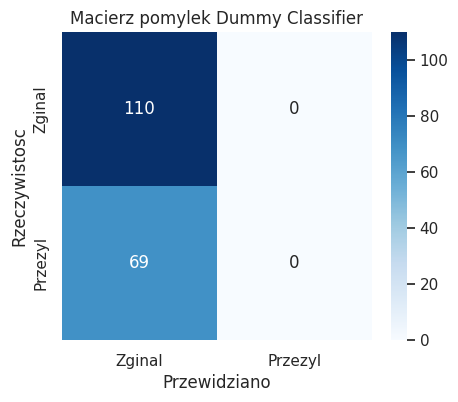

DummyClassifier(strategy='most_frequent')

In [33]:
dummy = DummyClassifier(strategy='most_frequent')
ocen_ostatecznie(dummy, X_train, y_train, X_test, y_test, 'Dummy Classifier')


5. MDOEL 1: DECISION TREE

do doboru paramow uzywalem petli i crossvalscore

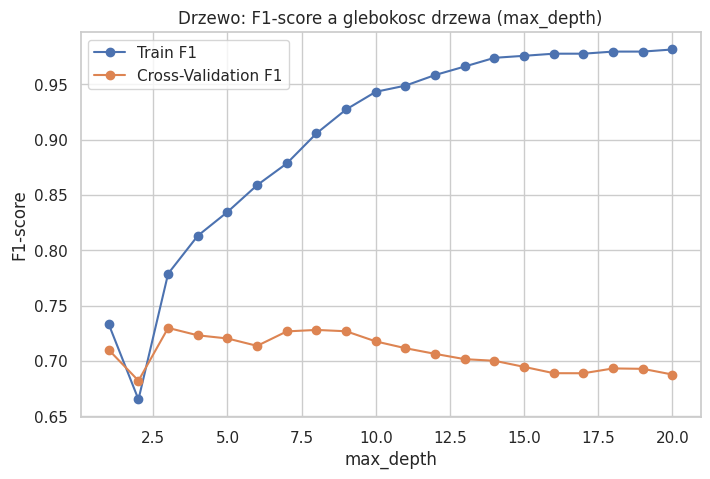

najlepsza glebokosc: 3


In [34]:
glebokosci = list(range(1, 21))
f1_train_dt = []
f1_cv_dt = []

for d in glebokosci:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    # wynik na calym zbiorze treningowym
    model.fit(X_train, y_train)
    f1_train_dt.append(f1_score(y_train, model.predict(X_train)))

    # walidacja krzyzowa (5 podzialow zbioru treningowego)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    f1_cv_dt.append(cv_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(glebokosci, f1_train_dt, label='Train F1', marker='o')
plt.plot(glebokosci, f1_cv_dt, label='Cross-Validation F1', marker='o')
plt.title('Drzewo: F1-score a glebokosc drzewa (max_depth)')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.legend()
plt.show()

# znalezienie najlepszej glebokosci uzywajac np.argmax
najlepsza_glebokosc = glebokosci[np.argmax(f1_cv_dt)]
print(f'najlepsza glebokosc: {najlepsza_glebokosc}')


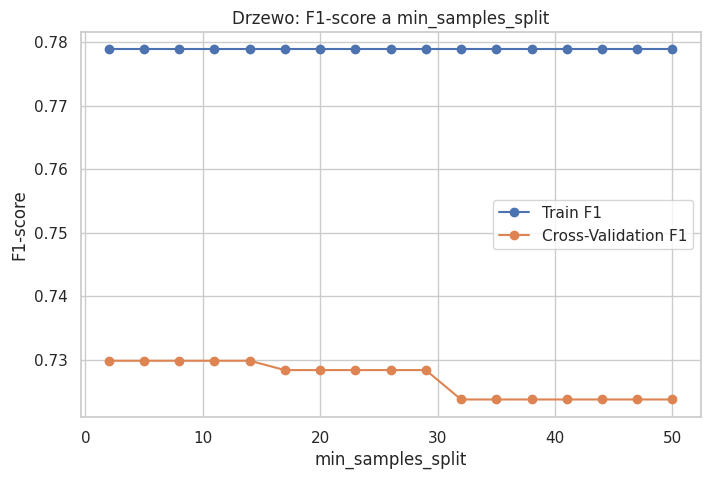

najlepszy min_samples_split: 2


In [35]:
splits = list(range(2, 51, 3))
f1_train_sp = []
f1_cv_sp = []

for s in splits:
    model = DecisionTreeClassifier(max_depth=najlepsza_glebokosc, min_samples_split=s, random_state=42)

    model.fit(X_train, y_train)
    f1_train_sp.append(f1_score(y_train, model.predict(X_train)))

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    f1_cv_sp.append(cv_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(splits, f1_train_sp, label='Train F1', marker='o')
plt.plot(splits, f1_cv_sp, label='Cross-Validation F1', marker='o')
plt.title('Drzewo: F1-score a min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('F1-score')
plt.legend()
plt.show()

najlepszy_split = splits[np.argmax(f1_cv_sp)]
print(f'najlepszy min_samples_split: {najlepszy_split}')


na wykresach widac kiedy nastepuje overfitting modelu

dla maxdepth bliskiego 20 drzewo ma prawie 100% na danych treningowych a na cross validation wynik spadaa bo model sie nauczyl danych na pamiec :(

dlatego sie uzywa np punktu maxdepth=5 zeby model mogl dobrze generalizowac

SZUKANIE NAJLEPSZYCH PARAMETROW DLA DRZEWA Z UZYCIEM GRIDSEARCHCV
najlepsze parametry drzewa: {'max_depth': 8, 'min_samples_split': 14}
Drzewo Decyzyjne (GridSearchCV)
WYNIKI TRENINGOWE:
accuracy: 0.9003
F1-score: 0.8658

WYNIKI TESTOWE:
accuracy: 0.7654
F1-score: 0.6957


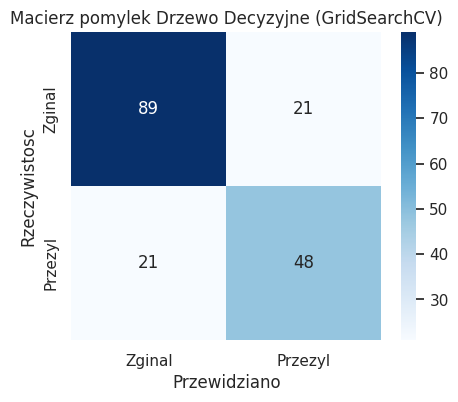

DecisionTreeClassifier(max_depth=8, min_samples_split=14, random_state=42)

In [36]:
print("SZUKANIE NAJLEPSZYCH PARAMETROW DLA DRZEWA Z UZYCIEM GRIDSEARCHCV")
parametry_dt = {
    'max_depth': list(range(1, 21)),
    'min_samples_split': list(range(2, 51, 3))
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), parametry_dt, cv=5, scoring='f1')
grid_dt.fit(X_train, y_train)

print(f"najlepsze parametry drzewa: {grid_dt.best_params_}")
dt_final = grid_dt.best_estimator_
ocen_ostatecznie(dt_final, X_train, y_train, X_test, y_test, 'Drzewo Decyzyjne (GridSearchCV)')


6. MODEL 2: KNN

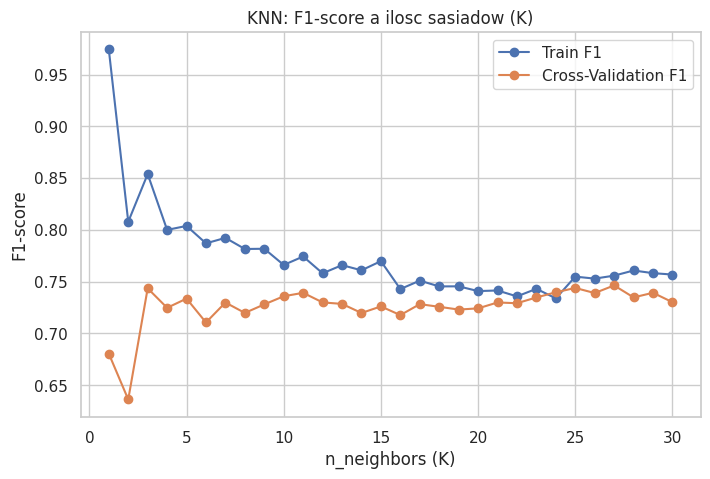

najlepsze K: 27


In [37]:
k_values = list(range(1, 31))
f1_train_knn = []
f1_cv_knn = []

for k in k_values:
    # pipeline chroni przed wyciekiem ze skalera
    model = make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=k))

    model.fit(X_train, y_train)
    f1_train_knn.append(f1_score(y_train, model.predict(X_train)))

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    f1_cv_knn.append(cv_scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_values, f1_train_knn, label='Train F1', marker='o')
plt.plot(k_values, f1_cv_knn, label='Cross-Validation F1', marker='o')
plt.title('KNN: F1-score a ilosc sasiadow (K)')
plt.xlabel('n_neighbors (K)')
plt.ylabel('F1-score')
plt.legend()
plt.show()

najlepsze_k = k_values[np.argmax(f1_cv_knn)]
print(f'najlepsze K: {najlepsze_k}')


In [38]:
wagi_opcje = ['uniform', 'distance']
wyniki_wag = {}

for w in wagi_opcje:
    model = make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=najlepsze_k, weights=w))
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    wyniki_wag[w] = cv_scores.mean()

najlepsza_waga = max(wyniki_wag, key=wyniki_wag.get)
print(f'porownanie wag: {wyniki_wag}')
print(f'najlepsza waga: {najlepsza_waga}')


porownanie wag: {'uniform': np.float64(0.7463693702430597), 'distance': np.float64(0.7293118497343152)}
najlepsza waga: uniform


dla K=1 KNN rowiez ma wynik rzedu 1.0 (100%) na danych treningowych (wskazuje sam na siebie)

oczywiscie zwiekszenie k zapobiega temu

SZUKANIE NAJLEPSZYCH PARAMETROW DLA KNN Z UZYCIEM GRIDSEARCHCV
najlepsze parametry KNN: {'kneighborsclassifier__n_neighbors': 27, 'kneighborsclassifier__weights': 'uniform'}
KNN (GridSearchCV)
WYNIKI TRENINGOWE:
accuracy: 0.8230
F1-score: 0.7558

WYNIKI TESTOWE:
accuracy: 0.7821
F1-score: 0.7068


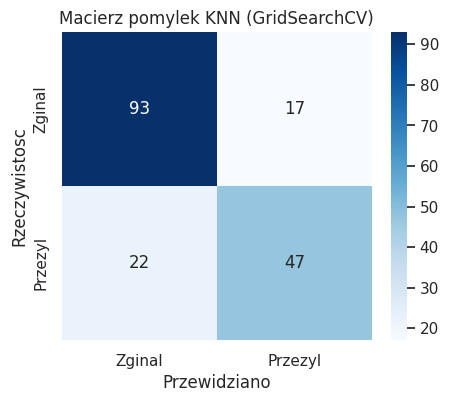

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Age', 'Fare'])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=27))])

In [39]:
print("SZUKANIE NAJLEPSZYCH PARAMETROW DLA KNN Z UZYCIEM GRIDSEARCHCV")
parametry_knn = {
    'kneighborsclassifier__n_neighbors': list(range(1, 31)),
    'kneighborsclassifier__weights': ['uniform', 'distance']
}
pipeline_knn = make_pipeline(preprocessor, KNeighborsClassifier())

grid_knn = GridSearchCV(pipeline_knn, parametry_knn, cv=5, scoring='f1')
grid_knn.fit(X_train, y_train)

print(f"najlepsze parametry KNN: {grid_knn.best_params_}")
knn_final = grid_knn.best_estimator_
ocen_ostatecznie(knn_final, X_train, y_train, X_test, y_test, 'KNN (GridSearchCV)')


7. PODSUMOWANIE

nie nastapil leak, a zbior testowy Xtest byl tylko do finalnego sprawdzenia; caly wybor paramow odbywal sie za pomoca walidacji na zbiorze Xtrain

dummy classifier zawsze strzelal 'zginal' osiagajac 61% Accuracy oraz F1-score 0. Ogolnie modele uzyskaly ok 80% skutecznosci

F1-score okazal sie niezbedny dla tak niezbalansowanego zbioru gdyz wskaznik Accuracy moze falszywie rosnac jesli mopdel faworyzowalby klase wiekszosciowa :(